In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn lightgbm xgboost shap jupyter

In [4]:
import pandas as pd
import numpy as np

# paths
train_transaction_path = r"C:\Users\zeina\OneDrive - McMaster University\GitProjects\fraud-risk-scoring-system\data\raw\train_transaction.csv"
train_identity_path = r"C:\Users\zeina\OneDrive - McMaster University\GitProjects\fraud-risk-scoring-system\data\raw\train_identity.csv"

# load datasets
train_transaction = pd.read_csv(train_transaction_path)
train_identity = pd.read_csv(train_identity_path)

# 1- Structural audit - schema and feature types

In [5]:
from pandas.api.types import (
    is_numeric_dtype,
    is_object_dtype,
    is_datetime64_any_dtype,
)

# --- 1. Basic column audit ---------------------------------------------------
print("train_transaction")
print(f"Rows: {train_transaction.shape[0]:,}")
print(f"Columns: {train_transaction.shape[1]:,}")
print()

print("train_identity")
print(f"Rows: {train_identity.shape[0]:,}")
print(f"Columns: {train_identity.shape[1]:,}")
print()


# --- 2. Confirm the join key exists in both datasets -------------------------
join_key = "TransactionID"

print(f"'{join_key}' in train_transaction:", join_key in train_transaction.columns)
print(f"'{join_key}' in train_identity:", join_key in train_identity.columns)
print()

if join_key in train_transaction.columns:
    print("train_transaction TransactionID duplicates:",
          train_transaction[join_key].duplicated().sum())

if join_key in train_identity.columns:
    print("train_identity TransactionID duplicates:",
          train_identity[join_key].duplicated().sum())

print()


# --- 3. Summarize data types -------------------------------------------------
def summarize_dtypes(df: pd.DataFrame, df_name: str) -> pd.DataFrame:
    """
    Create a compact schema summary for a dataframe.
    """
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "n_unique": df.nunique(dropna=True).values,
    })

    summary["dataset"] = df_name
    summary["type_group"] = np.where(
        summary["dtype"].isin(["int64", "float64", "int32", "float32"]),
        "numeric",
        np.where(summary["dtype"] == "object", "categorical/object", "other")
    )

    return summary[
        ["dataset", "column", "dtype", "type_group", "missing_count", "missing_pct", "n_unique"]
    ]


transaction_schema = summarize_dtypes(train_transaction, "train_transaction")
identity_schema = summarize_dtypes(train_identity, "train_identity")

print("Transaction dtype counts:")
print(transaction_schema["type_group"].value_counts())
print()

print("Identity dtype counts:")
print(identity_schema["type_group"].value_counts())
print()


# --- 4. Show representative columns by type ---------------------------------
transaction_numeric_cols = train_transaction.select_dtypes(include=["number"]).columns.tolist()
transaction_object_cols = train_transaction.select_dtypes(include=["object"]).columns.tolist()

identity_numeric_cols = train_identity.select_dtypes(include=["number"]).columns.tolist()
identity_object_cols = train_identity.select_dtypes(include=["object"]).columns.tolist()

print("First 15 numeric columns in train_transaction:")
print(transaction_numeric_cols[:15])
print()

print("First 15 categorical/object columns in train_transaction:")
print(transaction_object_cols[:15])
print()

print("First 15 numeric columns in train_identity:")
print(identity_numeric_cols[:15])
print()

print("First 15 categorical/object columns in train_identity:")
print(identity_object_cols[:15])
print()


# --- 5. Check TransactionID coverage between the two files -------------------
if join_key in train_transaction.columns and join_key in train_identity.columns:
    transaction_ids = set(train_transaction[join_key])
    identity_ids = set(train_identity[join_key])

    print("Identity rows as % of transaction rows:")
    print(f"{len(identity_ids) / len(transaction_ids):.2%}")
    print()

    print("TransactionIDs in identity but not in transaction:",
          len(identity_ids - transaction_ids))
    print("TransactionIDs in transaction but not in identity:",
          len(transaction_ids - identity_ids))
    print()


# --- 6. inspect schema tables directly ---------------------------------------

display(transaction_schema.head(20))
display(identity_schema.head(20))

train_transaction
Rows: 590,540
Columns: 394

train_identity
Rows: 144,233
Columns: 41

'TransactionID' in train_transaction: True
'TransactionID' in train_identity: True

train_transaction TransactionID duplicates: 0
train_identity TransactionID duplicates: 0

Transaction dtype counts:
type_group
numeric               380
categorical/object     14
Name: count, dtype: int64

Identity dtype counts:
type_group
numeric               24
categorical/object    17
Name: count, dtype: int64

First 15 numeric columns in train_transaction:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3']

First 15 categorical/object columns in train_transaction:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

First 15 numeric columns in train_identity:
['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_0

,dataset,column,dtype,type_group,missing_count,missing_pct,n_unique
0,train_transaction,TransactionID,int64,numeric,0,0.00,590540
1,train_transaction,isFraud,int64,numeric,0,0.00,2
2,train_transaction,TransactionDT,int64,numeric,0,0.00,573349
3,train_transaction,TransactionAmt,float64,numeric,0,0.00,20902
4,train_transaction,ProductCD,object,categorical/object,0,0.00,5
5,train_transaction,card1,int64,numeric,0,0.00,13553
6,train_transaction,card2,float64,numeric,8933,1.51,500
7,train_transaction,card3,float64,numeric,1565,0.27,114
8,train_transaction,card4,object,categorical/object,1577,0.27,4
9,train_transaction,card5,float64,numeric,4259,0.72,119


,dataset,column,dtype,type_group,missing_count,missing_pct,n_unique
0,train_identity,TransactionID,int64,numeric,0,0.00,144233
1,train_identity,id_01,float64,numeric,0,0.00,77
2,train_identity,id_02,float64,numeric,3361,2.33,115655
3,train_identity,id_03,float64,numeric,77909,54.02,24
4,train_identity,id_04,float64,numeric,77909,54.02,15
5,train_identity,id_05,float64,numeric,7368,5.11,93
6,train_identity,id_06,float64,numeric,7368,5.11,101
7,train_identity,id_07,float64,numeric,139078,96.43,84
8,train_identity,id_08,float64,numeric,139078,96.43,94
9,train_identity,id_09,float64,numeric,69307,48.05,46


# 2- Data quality checks: missingness, duplicates, sanity checks

In [6]:
# Not EDA yet, understand what is broken, sparse, duplicated, or suspicious.


# --- 1. Missing-value summary -----------------------------------------------
def summarize_missingness(df: pd.DataFrame, df_name: str) -> pd.DataFrame:
    """
    Build a compact missing-value summary for each column in a dataframe.
    This is useful before any merge, cleaning, or preprocessing decisions.
    """
    missing_summary = pd.DataFrame({
        "dataset": df_name,
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "dtype": df.dtypes.astype(str).values,
        "n_unique_non_null": df.nunique(dropna=True).values,
    })

    missing_summary = missing_summary.sort_values(
        by=["missing_pct", "missing_count"],
        ascending=False
    ).reset_index(drop=True)

    return missing_summary


transaction_missing = summarize_missingness(train_transaction, "train_transaction")
identity_missing = summarize_missingness(train_identity, "train_identity")


print("Top 15 columns with highest missingness in train_transaction:")
display(transaction_missing.head(15))

print("Top 15 columns with highest missingness in train_identity:")
display(identity_missing.head(15))


print("Missingness bands - train_transaction")
print("Columns with any missing values: ", (transaction_missing["missing_count"] > 0).sum())
print("Columns with > 50% missing:      ", (transaction_missing["missing_pct"] > 50).sum())
print("Columns with > 80% missing:      ", (transaction_missing["missing_pct"] > 80).sum())
print("Columns with > 95% missing:      ", (transaction_missing["missing_pct"] > 95).sum())
print()

print("Missingness bands - train_identity")
print("Columns with any missing values: ", (identity_missing["missing_count"] > 0).sum())
print("Columns with > 50% missing:      ", (identity_missing["missing_pct"] > 50).sum())
print("Columns with > 80% missing:      ", (identity_missing["missing_pct"] > 80).sum())
print("Columns with > 95% missing:      ", (identity_missing["missing_pct"] > 95).sum())
print()


# --- 2. Full-row duplicate checks -------------------------------------------
transaction_full_duplicates = train_transaction.duplicated().sum()
identity_full_duplicates = train_identity.duplicated().sum()

print("Full-row duplicate count")
print(f"train_transaction: {transaction_full_duplicates:,}")
print(f"train_identity:    {identity_full_duplicates:,}")
print()


# --- 3. Join-key duplicate checks -------------------------------------------
# We already checked TransactionID structurally, double check here because
# duplicate keys would break the one-row-per-transaction assumption.

join_key = "TransactionID"

transaction_key_duplicates = train_transaction[join_key].duplicated().sum()
identity_key_duplicates = train_identity[join_key].duplicated().sum()

print(f"Duplicate {join_key} values")
print(f"train_transaction: {transaction_key_duplicates:,}")
print(f"train_identity:    {identity_key_duplicates:,}")
print()


# --- 4. Simple sanity checks -------------------------------------------------
sanity_checks = {
    "transaction_amount_negative": (train_transaction["TransactionAmt"] < 0).sum(),
    "transaction_amount_zero": (train_transaction["TransactionAmt"] == 0).sum(),
    "transaction_dt_negative": (train_transaction["TransactionDT"] < 0).sum(),
    "target_missing": train_transaction["isFraud"].isna().sum(),
    "target_outside_0_1": (~train_transaction["isFraud"].isin([0, 1])).sum(),
}

print("Sanity checks")
for check_name, check_value in sanity_checks.items():
    print(f"{check_name}: {check_value:,}")
print()


# --- 5. Quick numeric range review for key fields ---------------------------
# This is not full EDA. It is just a compact reality check for core fields.

key_numeric_cols = ["TransactionAmt", "TransactionDT", "isFraud"]

numeric_range_summary = pd.DataFrame({
    "column": key_numeric_cols,
    "min": [train_transaction[col].min() for col in key_numeric_cols],
    "max": [train_transaction[col].max() for col in key_numeric_cols],
    "mean": [train_transaction[col].mean() for col in key_numeric_cols],
    "missing_count": [train_transaction[col].isna().sum() for col in key_numeric_cols],
})

print("Key numeric field range check:")
display(numeric_range_summary)


# --- 6. save summaries for reuse later -----------------------------------

data_quality_summary = {
    "transaction_missing": transaction_missing,
    "identity_missing": identity_missing,
    "numeric_range_summary": numeric_range_summary,
}

Top 15 columns with highest missingness in train_transaction:


,dataset,column,missing_count,missing_pct,dtype,n_unique_non_null
0,train_transaction,dist2,552913,93.63,float64,1751
1,train_transaction,D7,551623,93.41,float64,597
2,train_transaction,D13,528588,89.51,float64,577
3,train_transaction,D14,528353,89.47,float64,802
4,train_transaction,D12,525823,89.04,float64,635
5,train_transaction,D6,517353,87.61,float64,829
6,train_transaction,D8,515614,87.31,float64,12353
7,train_transaction,D9,515614,87.31,float64,24
8,train_transaction,V138,508595,86.12,float64,23
9,train_transaction,V139,508595,86.12,float64,34


Top 15 columns with highest missingness in train_identity:


,dataset,column,missing_count,missing_pct,dtype,n_unique_non_null
0,train_identity,id_24,139486,96.71,float64,12
1,train_identity,id_25,139101,96.44,float64,341
2,train_identity,id_07,139078,96.43,float64,84
3,train_identity,id_08,139078,96.43,float64,94
4,train_identity,id_21,139074,96.42,float64,490
5,train_identity,id_26,139070,96.42,float64,95
6,train_identity,id_22,139064,96.42,float64,25
7,train_identity,id_23,139064,96.42,object,3
8,train_identity,id_27,139064,96.42,object,2
9,train_identity,id_18,99120,68.72,float64,18


Missingness bands - train_transaction
Columns with any missing values:  374
Columns with > 50% missing:       174
Columns with > 80% missing:       55
Columns with > 95% missing:       0

Missingness bands - train_identity
Columns with any missing values:  38
Columns with > 50% missing:       12
Columns with > 80% missing:       9
Columns with > 95% missing:       9

Full-row duplicate count
train_transaction: 0
train_identity:    0

Duplicate TransactionID values
train_transaction: 0
train_identity:    0

Sanity checks
transaction_amount_negative: 0
transaction_amount_zero: 0
transaction_dt_negative: 0
target_missing: 0
target_outside_0_1: 0

Key numeric field range check:


,column,min,max,mean,missing_count
0,TransactionAmt,0.251,3.193739e+04,1.350272e+02,0
1,TransactionDT,86400.000,1.581113e+07,7.372311e+06,0
2,isFraud,0.000,1.000000e+00,3.499001e-02,0


# 3- Create the holdout test set
## 3.1- inspect the proper split design: time split, group split, stratified split, random split?

TransactionDT checks
Missing values: 0
Duplicate values: 17,191
Min value: 86,400
Max value: 15,811,131

Ordering check
Rows already sorted by TransactionDT: True

TransactionDT summary:


,count,mean,std,min,25%,50%,75%,max
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.0,3027057.75,7306527.5,11246620.0,15811131.0


Fraud rate by TransactionDT bucket:


,time_bin,n_transactions,fraud_count,fraud_rate,min_dt,max_dt,fraud_rate_pct
0,"(86399.999, 1361004.4]",59054,1631,0.027619,86400,1360999,2.762
1,"(1361004.4, 2310159.6]",59054,1195,0.020236,1361005,2310138,2.024
2,"(2310159.6, 3864163.9]",59054,2200,0.037254,2310165,3864159,3.725
3,"(3864163.9, 5592303.6]",59054,2532,0.042876,3864166,5592303,4.288
4,"(5592303.6, 7306527.5]",59054,2336,0.039557,5592304,7306520,3.956
5,"(7306527.5, 8745782.4]",59054,2094,0.035459,7306535,8745772,3.546
6,"(8745782.4, 10437998.1]",59054,2550,0.043181,8745798,10437996,4.318
7,"(10437998.1, 12192853.6]",59054,2061,0.034900,10438003,12192842,3.490
8,"(12192853.6, 13990907.7]",59054,1851,0.031344,12192900,13990904,3.134
9,"(13990907.7, 15811131.0]",59054,2213,0.037474,13990941,15811131,3.747


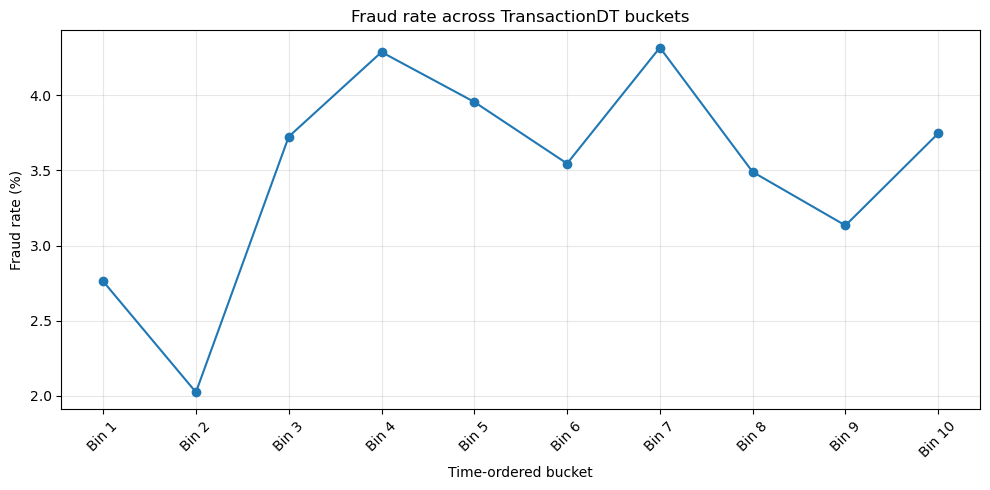

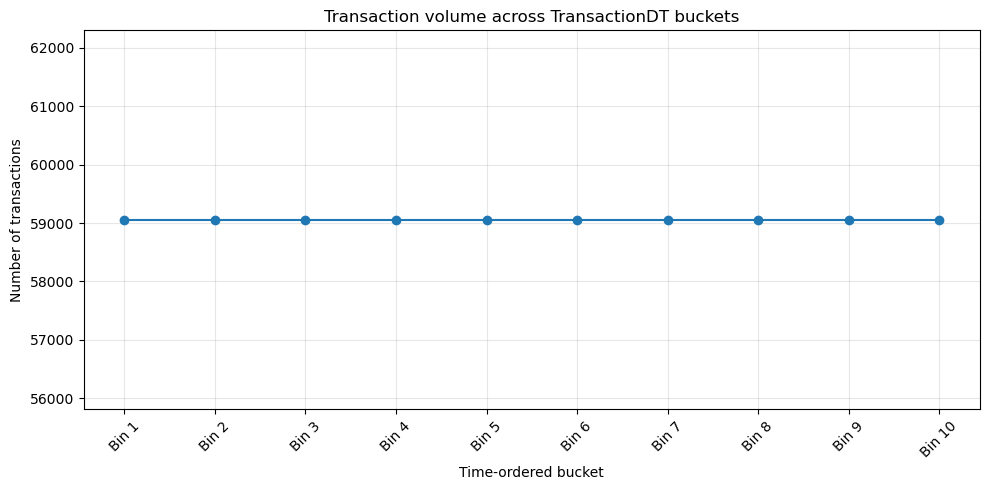

Split design note
- TransactionDT provides a usable transaction ordering variable.
- If fraud rate shifts over time, a random split can look too optimistic.
- A time-based holdout is more realistic for fraud-risk modeling.


In [7]:
# Fraud analysis: better to train on  past -> predict on future 
# 1) confirm that TransactionDT can be used as a time-ordering field
# 2) inspect target behavior over time before choosing the split rule
import matplotlib.pyplot as plt

split_time_col = "TransactionDT"
target_col = "isFraud"

# --- 1. Basic checks for the time field -------------------------------------
print("TransactionDT checks")
print(f"Missing values: {(train_transaction[split_time_col].isna().sum()):,}")
print(f"Duplicate values: {(train_transaction[split_time_col].duplicated().sum()):,}")
print(f"Min value: {train_transaction[split_time_col].min():,}")
print(f"Max value: {train_transaction[split_time_col].max():,}")
print()


# --- 2. Confirm row ordering vs time ordering -------------------------------
# This checks whether the file is already sorted by TransactionDT.

is_time_sorted = train_transaction[split_time_col].is_monotonic_increasing

print("Ordering check")
print(f"Rows already sorted by TransactionDT: {is_time_sorted}")
print()


# --- 3. Quick descriptive summary -------------------------------------------
time_summary = train_transaction[split_time_col].describe().to_frame().T
print("TransactionDT summary:")
display(time_summary)


# --- 4. Build time bins for trend inspection --------------------------------
# We use quantile bins so each bucket has a similar number of observations.

n_time_bins = 10

time_profile = train_transaction[[split_time_col, target_col]].copy()
time_profile["time_bin"] = pd.qcut(
    time_profile[split_time_col],
    q=n_time_bins,
    duplicates="drop"
)

time_bin_summary = (
    time_profile
    .groupby("time_bin", observed=False)
    .agg(
        n_transactions=(target_col, "size"),
        fraud_count=(target_col, "sum"),
        fraud_rate=(target_col, "mean"),
        min_dt=(split_time_col, "min"),
        max_dt=(split_time_col, "max"),
    )
    .reset_index()
)

time_bin_summary["fraud_rate_pct"] = (time_bin_summary["fraud_rate"] * 100).round(3)

print("Fraud rate by TransactionDT bucket:")
display(time_bin_summary)


# --- 5. Plot fraud rate over time bins --------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(
    range(len(time_bin_summary)),
    time_bin_summary["fraud_rate_pct"],
    marker="o"
)
plt.xticks(range(len(time_bin_summary)), [f"Bin {i+1}" for i in range(len(time_bin_summary))], rotation=45)
plt.ylabel("Fraud rate (%)")
plt.xlabel("Time-ordered bucket")
plt.title("Fraud rate across TransactionDT buckets")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 6. Plot transaction volume over time bins ------------------------------
plt.figure(figsize=(10, 5))
plt.plot(
    range(len(time_bin_summary)),
    time_bin_summary["n_transactions"],
    marker="o"
)
plt.xticks(range(len(time_bin_summary)), [f"Bin {i+1}" for i in range(len(time_bin_summary))], rotation=45)
plt.ylabel("Number of transactions")
plt.xlabel("Time-ordered bucket")
plt.title("Transaction volume across TransactionDT buckets")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --- 7. Split-design note ----------------------------------------------------
print("Split design note")
print("- TransactionDT provides a usable transaction ordering variable.")
print("- If fraud rate shifts over time, a random split can look too optimistic.")
print("- A time-based holdout is more realistic for fraud-risk modeling.")

## 3.2- Create holdout test set : a time-based holdout using TransactionDT

In [8]:
# train on earlier transactions, test on later transactions.

split_time_col = "TransactionDT"
target_col = "isFraud"
holdout_fraction = 0.20

# --- 1. Sort by time --------------------------------------------------------
transaction_sorted = train_transaction.sort_values(split_time_col).reset_index(drop=True)

# --- 2. Find split index ----------------------------------------------------
split_idx = int(len(transaction_sorted) * (1 - holdout_fraction))

# --- 3. Split transaction table --------------------------------------------
train_transaction_dev = transaction_sorted.iloc[:split_idx].copy()
test_transaction_holdout = transaction_sorted.iloc[split_idx:].copy()

# --- 4. Basic shape check ---------------------------------------------------
print("Transaction split shapes")
print(f"Development set: {train_transaction_dev.shape}")
print(f"Holdout test set: {test_transaction_holdout.shape}")
print()

# --- 5. Time range check ----------------------------------------------------
print("TransactionDT ranges")
print(
    f"Development: {train_transaction_dev[split_time_col].min():,} "
    f"to {train_transaction_dev[split_time_col].max():,}"
)
print(
    f"Holdout test: {test_transaction_holdout[split_time_col].min():,} "
    f"to {test_transaction_holdout[split_time_col].max():,}"
)
print()

# --- 6. Target balance check ------------------------------------------------
split_target_summary = pd.DataFrame({
    "split": ["development", "holdout_test"],
    "n_rows": [len(train_transaction_dev), len(test_transaction_holdout)],
    "fraud_count": [
        train_transaction_dev[target_col].sum(),
        test_transaction_holdout[target_col].sum(),
    ],
    "fraud_rate": [
        train_transaction_dev[target_col].mean(),
        test_transaction_holdout[target_col].mean(),
    ],
})

split_target_summary["fraud_rate_pct"] = (split_target_summary["fraud_rate"] * 100).round(3)

print("Target distribution by split:")
display(split_target_summary)

# --- 7. Split identity table using TransactionID ----------------------------
# Identity data is attached after the transaction split to avoid mixing future rows.

dev_ids = set(train_transaction_dev["TransactionID"])
test_ids = set(test_transaction_holdout["TransactionID"])

train_identity_dev = train_identity[train_identity["TransactionID"].isin(dev_ids)].copy()
test_identity_holdout = train_identity[train_identity["TransactionID"].isin(test_ids)].copy()

print("Identity split shapes")
print(f"Development identity set: {train_identity_dev.shape}")
print(f"Holdout identity set:     {test_identity_holdout.shape}")
print()

# --- 8. Identity coverage check --------------------------------------------
#What % of transactions have identity information?
dev_identity_coverage = train_transaction_dev["TransactionID"].isin(
    train_identity_dev["TransactionID"]
).mean()

test_identity_coverage = test_transaction_holdout["TransactionID"].isin(
    test_identity_holdout["TransactionID"]
).mean()

print("Identity coverage by split")
print(f"Development: {dev_identity_coverage:.2%}")
print(f"Holdout test: {test_identity_coverage:.2%}")
print()

# --- 9. Save split objects for later ------------------------------

X_dev_transaction = train_transaction_dev.drop(columns=[target_col])
y_dev = train_transaction_dev[target_col].copy()

X_test_transaction = test_transaction_holdout.drop(columns=[target_col])
y_test = test_transaction_holdout[target_col].copy()

print("Final split objects created")
print(f"X_dev_transaction: {X_dev_transaction.shape}")
print(f"y_dev: {y_dev.shape}")
print(f"X_test_transaction: {X_test_transaction.shape}")
print(f"y_test: {y_test.shape}")

Transaction split shapes
Development set: (472432, 394)
Holdout test set: (118108, 394)

TransactionDT ranges
Development: 86,400 to 12,192,842
Holdout test: 12,192,900 to 15,811,131

Target distribution by split:


,split,n_rows,fraud_count,fraud_rate,fraud_rate_pct
0,development,472432,16599,0.035135,3.514
1,holdout_test,118108,4064,0.034409,3.441


Identity split shapes
Development identity set: (120464, 41)
Holdout identity set:     (23769, 41)

Identity coverage by split
Development: 25.50%
Holdout test: 20.12%

Final split objects created
X_dev_transaction: (472432, 393)
y_dev: (472432,)
X_test_transaction: (118108, 393)
y_test: (118108,)


# 4- EDA on training data
## 4.1- Build development analysis dataset

In [9]:
join_key = "TransactionID"

dev_df = train_transaction_dev.merge(
    train_identity_dev,
    on=join_key,
    how="left"
)

print("Development analysis dataset shape:")
print(dev_df.shape)
print()

# Check that row count stayed consistent
print("Row check")
print("transaction rows:", train_transaction_dev.shape[0])
print("merged rows:", dev_df.shape[0])
print()

# Target distribution in merged dataset
print("Fraud rate in development dataset:")
print(dev_df["isFraud"].value_counts(normalize=True))

Development analysis dataset shape:
(472432, 434)

Row check
transaction rows: 472432
merged rows: 472432

Fraud rate in development dataset:
isFraud
0    0.964865
1    0.035135
Name: proportion, dtype: float64


In [11]:
# Persist prepared datasets for downstream notebooks
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

dev_df.to_parquet(output_dir / "dev_df.parquet", index=False)

test_transaction_holdout.to_parquet(
    output_dir / "test_transaction_holdout.parquet",
    index=False
)

test_identity_holdout.to_parquet(
    output_dir / "test_identity_holdout.parquet",
    index=False
)

print("Datasets saved successfully.")
print("Saved to:", output_dir.resolve())

Datasets saved successfully.
Saved to: C:\Users\zeina\data\processed
